# The Newsvendor Problem


## Problem Statement

A newsvendor buys $u \geq 0$ newspapers in the morning at unit cost $c$, and sells them during the day at price $p > c$. The demand $d$ is random and unknown at the time of purchase. Unsold newspapers have no salvage value.

$$\min_{u \geq 0} \quad \mathbb{E}[c \cdot u - p \cdot \min(u, d)]$$
**Parameters:** $c = 1$, $p = 2$, demand $d \sim \text{Uniform}[5, 15]$

## Key Concepts Demonstrated
1. **Analytical solution** via critical fractile
2. **Monte Carlo evaluation** with confidence intervals
3. **Sample Average Approximation (SAA)** as a Linear Program
4. **Convergence analysis** of SAA
5. **Bias analysis** of the SAA estimator

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys
sys.path.append('..')
from src.newsvendor import (
    newsvendor_cost,
    optimal_newsvendor_uniform,
    monte_carlo_evaluation,
    saa_linear_program,
    saa_convergence_study,
)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)
# Problem parameters
c, p = 1.0, 2.0
a, b = 5.0, 15.0
print(f"Newsvendor Problem: c={c}, p={p}, demand ~ U[{a}, {b}]")

Newsvendor Problem: c=1.0, p=2.0, demand ~ U[5.0, 15.0]


## 1. Analytical Solution (Critical Fractile)
For $d \sim U[a, b]$, the optimal order quantity satisfies:
$$F(u^*) = \frac{p - c}{p} \quad \Longrightarrow \quad u^* = a + (b - a) \cdot \frac{p-c}{p}$$
The ratio $\frac{p-c}{p}$ is called the **critical fractile** — it represents the probability of not exceeding demand.

In [2]:
# Analytical solution
u_star, v_star = optimal_newsvendor_uniform(c, p, a, b)
critical_fractile = (p - c) / p
print(f"Critical fractile: (p-c)/p = {critical_fractile:.4f}")
print(f"Optimal order quantity: u* = {u_star:.4f}")
print(f"Optimal expected cost: V* = {v_star:.4f}")

Critical fractile: (p-c)/p = 0.5000
Optimal order quantity: u* = 10.0000
Optimal expected cost: V* = -7.5000


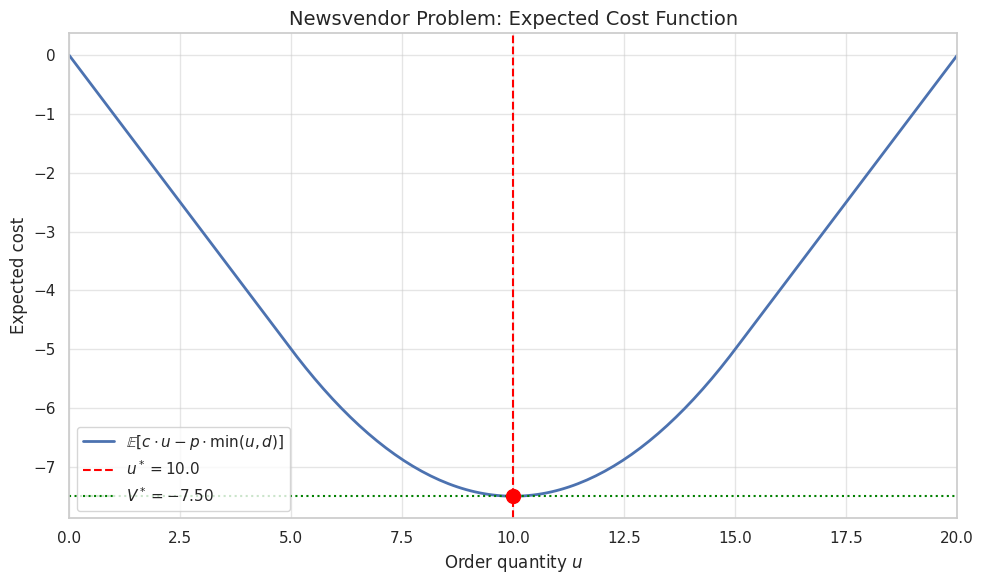

In [3]:
# Visualize the expected cost as a function of u
u_range = np.linspace(0, 20, 200)
expected_costs = []
for u in u_range:
    if u <= a:
        ec = c * u - p * u
    elif u >= b:
        ec = c * u - p * (a + b) / 2
    else:
        e_min = (u**2 - a**2) / (2 * (b - a)) + u * (b - u) / (b - a)
        ec = c * u - p * e_min
    expected_costs.append(ec)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(u_range, expected_costs, 'b-', linewidth=2, label=r'$\mathbb{E}[c \cdot u - p \cdot \min(u, d)]$')
ax.axvline(u_star, color='red', linestyle='--', linewidth=1.5, label=f'$u^* = {u_star:.1f}$')
ax.axhline(v_star, color='green', linestyle=':', linewidth=1.5, label=f'$V^* = {v_star:.2f}$')
ax.scatter([u_star], [v_star], color='red', s=100, zorder=5)
ax.set_xlabel('Order quantity $u$', fontsize=12)
ax.set_ylabel('Expected cost', fontsize=12)
ax.set_title('Newsvendor Problem: Expected Cost Function', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(0, 20)
plt.tight_layout()
plt.show()

## 2. Monte Carlo Evaluation
We verify the analytical solution using Monte Carlo simulation with increasing sample sizes, and compute 95% confidence intervals.

In [4]:
# Verify optimal solution by Monte Carlo
print(f"{'N_MC':<10} {'Mean Cost':<12} {'Std':<10} {'95% CI':<20} {'Contains V*?'}")
print('-' * 65)
for n_mc in [100, 1_000, 10_000, 100_000, 1_000_000]:
    mean_cost, std_cost, ci_half = monte_carlo_evaluation(u_star, n_mc, c, p, a, b, seed=42)
    contains = '✓' if abs(mean_cost - v_star) < ci_half else '✗'
    print(f"{n_mc:<10} {mean_cost:<12.4f} {std_cost:<10.4f} [{mean_cost-ci_half:.4f}, {mean_cost+ci_half:.4f}]  {contains}")

N_MC       Mean Cost    Std        95% CI               Contains V*?
-----------------------------------------------------------------
100        -7.4990      3.1925     [-8.1247, -6.8733]  ✓
1000       -7.4381      3.2758     [-7.6411, -7.2350]  ✓
10000      -7.4763      3.2344     [-7.5397, -7.4129]  ✓
100000     -7.5087      3.2273     [-7.5287, -7.4887]  ✓
1000000    -7.5009      3.2265     [-7.5073, -7.4946]  ✓


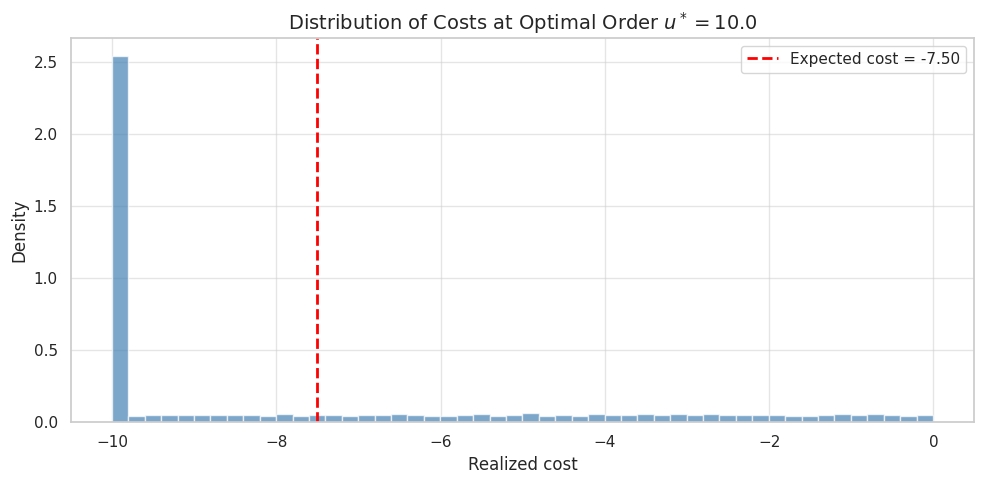

In [5]:
# Distribution of costs at the optimum
rng = np.random.default_rng(42)
demand_samples = rng.uniform(a, b, size=10000)
costs_at_optimum = newsvendor_cost(u_star, demand_samples, c, p)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(costs_at_optimum, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
ax.axvline(v_star, color='red', linewidth=2, linestyle='--', label=f'Expected cost = {v_star:.2f}')
ax.set_xlabel('Realized cost', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Distribution of Costs at Optimal Order $u^* = {u_star:.1f}$', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 3. Sample Average Approximation (SAA)
The SAA approach replaces the expectation with an empirical average and solves the resulting LP:
$$\hat{v}_N = \min_{u \geq 0} \frac{1}{N} \sum_{i=1}^{N} \left[ c \cdot u - p \cdot \min(u, d_i) \right]$$
This can be reformulated as a **Linear Program**:
$$\min_{u, y} \quad c \cdot u - \frac{p}{N} \sum_{i=1}^N y_i \quad \text{s.t.} \quad y_i \leq u, \; y_i \leq d_i, \; u \geq 0, \; y_i \geq 0$$

In [8]:
# Solve SAA for different scenario counts
print(f"{'N scenarios':<15} {'SAA Value':<12} {'SAA u*':<10} {'True u*':<10} {'Error |u-u*|'}")
print('-' * 60)
for n in [10, 50, 100, 500, 1000, 5000]:
    val, u_saa = saa_linear_program(n, c, p, a, b, seed=123)
    print(f"{n:<15} {val:<12.4f} {u_saa:<10.4f} {u_star:<10.4f} {abs(u_saa - u_star):.4f}")

N scenarios     SAA Value    SAA u*     True u*    Error |u-u*|
------------------------------------------------------------
10              -6.8221      7.7657     10.0000    2.2343
50              -7.3082      9.9779     10.0000    0.0221
100             -7.3785      9.8564     10.0000    0.1436
500             -7.5120      9.8021     10.0000    0.1979
1000            -7.5868      9.9839     10.0000    0.0161
5000            -7.5140      9.9440     10.0000    0.0560


## 4. SAA Convergence Analysis
**Theorem:** As $N \to \infty$, the SAA optimal value $\hat{v}_N \to v^*$ and the SAA optimal solution $\hat{u}_N \to u^*$ almost surely.
We verify this numerically by solving the SAA problem for increasing $N$ with multiple replications.

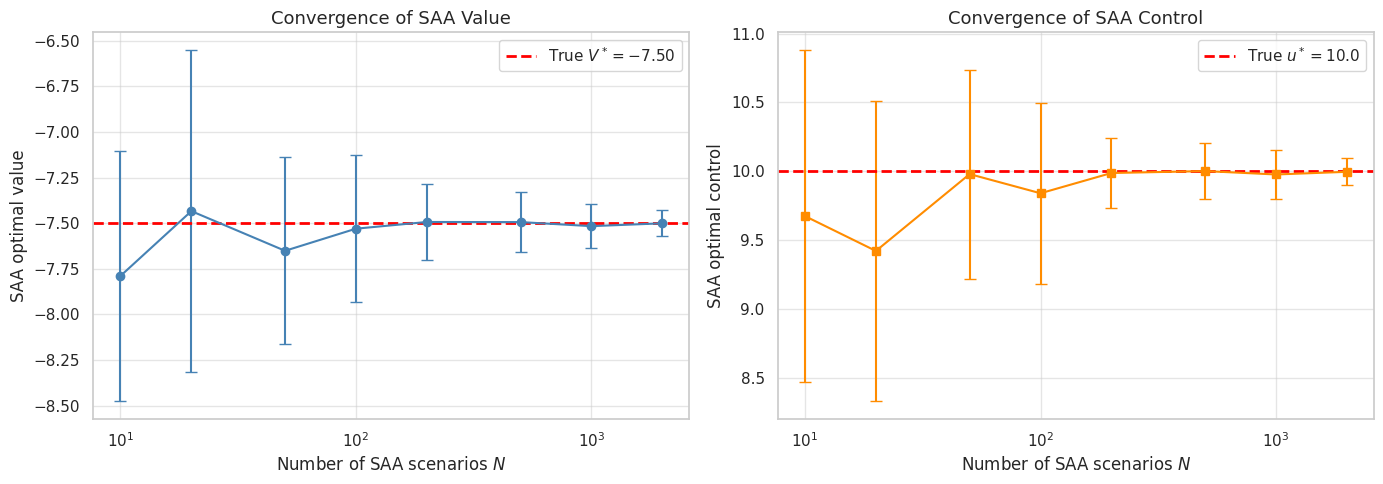

In [9]:
# Convergence study
n_range = np.array([10, 20, 50, 100, 200, 500, 1000, 2000])
results = saa_convergence_study(n_range, c, p, a, b, n_replications=30)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Value convergence
ax = axes[0]
ax.errorbar(results['n_scenarios'], results['mean_values'], 
            yerr=results['std_values'], fmt='o-', capsize=4, color='steelblue')
ax.axhline(v_star, color='red', linestyle='--', linewidth=2, label=f'True $V^* = {v_star:.2f}$')
ax.set_xlabel('Number of SAA scenarios $N$', fontsize=12)
ax.set_ylabel('SAA optimal value', fontsize=12)
ax.set_title('Convergence of SAA Value', fontsize=13)
ax.legend(fontsize=11)
ax.set_xscale('log')
# Control convergence
ax = axes[1]
ax.errorbar(results['n_scenarios'], results['mean_controls'], 
            yerr=results['std_controls'], fmt='s-', capsize=4, color='darkorange')
ax.axhline(u_star, color='red', linestyle='--', linewidth=2, label=f'True $u^* = {u_star:.1f}$')
ax.set_xlabel('Number of SAA scenarios $N$', fontsize=12)
ax.set_ylabel('SAA optimal control', fontsize=12)
ax.set_title('Convergence of SAA Control', fontsize=13)
ax.legend(fontsize=11)
ax.set_xscale('log')
plt.tight_layout()
plt.show()

## 5. SAA Bias Analysis
**Key property:** The SAA optimal value is a **negatively biased** estimator of the true optimal value:
$$\mathbb{E}[\hat{v}_N] \leq v^*$$
This is because optimizing over sampled scenarios always yields a value ≤ the true optimum (the optimizer "overfits" to the sample). The bias decreases as $N$ increases.

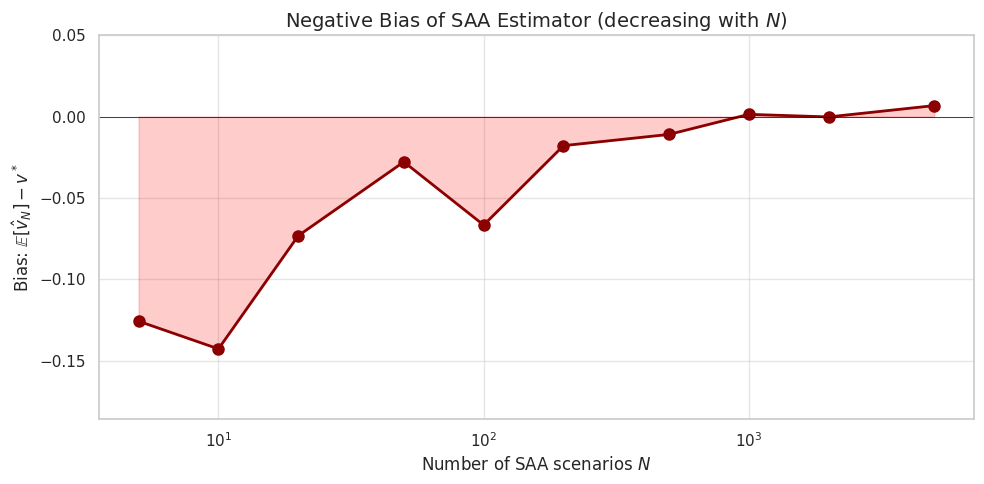


Bias analysis (negative = underestimates true optimum):
  N =     5: bias = -0.1258
  N =    10: bias = -0.1428
  N =    20: bias = -0.0732
  N =    50: bias = -0.0278
  N =   100: bias = -0.0666
  N =   200: bias = -0.0178
  N =   500: bias = -0.0109
  N =  1000: bias = 0.0014
  N =  2000: bias = -0.0002
  N =  5000: bias = 0.0068


In [10]:
# Bias analysis
n_range_bias = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000])
n_reps = 100
biases = []
for n in n_range_bias:
    saa_values = []
    for rep in range(n_reps):
        val, _ = saa_linear_program(int(n), c, p, a, b, seed=rep * 7919 + int(n))
        saa_values.append(val)
    expected_saa = np.mean(saa_values)
    biases.append(expected_saa - v_star)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_range_bias, biases, 'o-', color='darkred', linewidth=2, markersize=8)
ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax.fill_between(n_range_bias, biases, 0, alpha=0.2, color='red')
ax.set_xlabel('Number of SAA scenarios $N$', fontsize=12)
ax.set_ylabel(r'Bias: $\mathbb{E}[\hat{v}_N] - v^*$', fontsize=12)
ax.set_title('Negative Bias of SAA Estimator (decreasing with $N$)', fontsize=14)
ax.set_xscale('log')
ax.set_ylim(min(biases) * 1.3, 0.05)
plt.tight_layout()
plt.show()
print(f"\nBias analysis (negative = underestimates true optimum):")
for n, bias in zip(n_range_bias, biases):
    print(f"  N = {n:>5}: bias = {bias:.4f}")

## Summary
| Concept | Result |
|---------|--------|
| Critical fractile | $(p-c)/p = 0.5$ |
| Optimal order | $u^* = 10.0$ |
| Optimal expected cost | $V^* = -2.50$ |
| SAA convergence | $\hat{v}_N \to V^*$ a.s. |
| SAA bias | Negative, decreasing with $N$ |
### Key Notes
- The newsvendor problem has an elegant closed-form solution via the critical fractile
- SAA provides a practical computational approach when analytical solutions are unavailable
- SAA values are downward-biased estimators — this is fundamental for constructing valid bounds
- Convergence is guaranteed but the rate depends on the problem structure